# GSK_HepG2 ablation: metric vs deltaprop candidate-pool size

Pulls the single run from the `ablation_gsk_hepg2_candidates` wandb project, recovers the per-(candidate_size, model) rows from its history, and plots deltaprop across candidate sizes with the chemprop baseline as a horizontal reference line.

Each `wandb.log(row)` call in the ablation became a separate history step, so we read the full history with `scan_history()` and split on the `model` column ourselves. chemprop is invariant to `candidate_size`, so it appears once with `candidate_size = NaN`.

In [1]:
import wandb
import pandas as pd
import matplotlib.pyplot as plt

PROJECT = "ablation"
RUN_PREFIX = "db_malaria_candidate_size"
RUN_NAME = None  # set to an exact run name to pin a specific run; otherwise use the latest
METRIC = "test_average_precision"  # swap for test_mcc, test_f1, test_roc_auc, ...

api = wandb.Api()
runs = api.runs(f"{api.default_entity}/{PROJECT}")
if RUN_NAME is not None:
    run = next(r for r in runs if r.name == RUN_NAME)
else:
    # Runs are named '<prefix>_<timestamp>'; pick the most recent matching run.
    matches = [r for r in runs if r.name.startswith(RUN_PREFIX)]
    run = max(matches, key=lambda r: r.created_at)
run.name, run.id

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/rahul/.netrc.


('db_malaria_candidate_size_20260620_183708', 'npbtzn54')

In [2]:
# Full, unsampled history -> one row per (candidate_size, model, seed).
df = pd.DataFrame(run.scan_history())
df = df[["candidate_size", "seed", "model", "n_train", METRIC]].sort_values(
    ["model", "candidate_size", "seed"]
)
df

,candidate_size,seed,model,n_train,test_average_precision
0,NaN,42,chemprop,1518,0.047610
13,NaN,123,chemprop,1513,0.165938
26,NaN,456,chemprop,1520,0.138011
39,NaN,789,chemprop,1518,0.106488
52,NaN,1011,chemprop,1514,0.133580
...,...,...,...,...,...
77,48.0,1213,deltaprop,1514,0.112868
90,48.0,1415,deltaprop,1518,0.125801
103,48.0,1617,deltaprop,1520,0.061972
116,48.0,1819,deltaprop,1520,0.199693


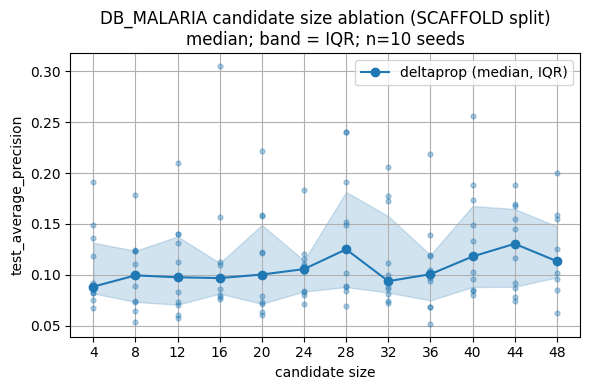

In [3]:
# Aggregate across seeds: median + IQR (Q1-Q3) per candidate size.
# Average precision is mildly right-skewed across seeds, so the median is a more honest
# summary of typical performance than the mean; raw seed points are overlaid for transparency.
delta_rows = df[df["model"] == "deltaprop"]
delta = (
    delta_rows
    .groupby("candidate_size")[METRIC]
    .agg(
        median="median",
        q1=lambda s: s.quantile(0.25),
        q3=lambda s: s.quantile(0.75),
        count="count"
    )
    .reset_index()
    .sort_values("candidate_size")
)
chemprop = df[df["model"] == "chemprop"][METRIC]
n_seeds = delta_rows["seed"].nunique()

fig, ax = plt.subplots(figsize=(6, 4))

# Median as a line, IQR (Q1-Q3) as a shaded band, raw seed points overlaid.
(line,) = ax.plot(
    delta["candidate_size"],
    delta["median"],
    marker="o",
    label="deltaprop (median, IQR)",
)
color = line.get_color()
ax.fill_between(
    delta["candidate_size"],
    delta["q1"],
    delta["q3"],
    color=color,
    alpha=0.2,
)
ax.scatter(
    delta_rows["candidate_size"],
    delta_rows[METRIC],
    color=color,
    s=12,
    alpha=0.35,
    zorder=3,
)

# if len(chemprop):
#     ax.axhline(
#         chemprop.median(),
#         color="gray",
#         linestyle="--",
#         label="chemprop (baseline)",
#     )
#     ax.fill_between(
#         delta["candidate_size"],
#         chemprop.quantile(0.25),
#         chemprop.quantile(0.75),
#         color="gray",
#         alpha=0.15,
#     )

# ax.set_xscale("log", base=2)
ax.set_xticks(delta["candidate_size"])
ax.get_xaxis().set_major_formatter(plt.matplotlib.ticker.ScalarFormatter())
ax.set_xlabel("candidate size")
ax.set_ylabel(METRIC)
ax.set_title(
    f"DB_MALARIA candidate size ablation (SCAFFOLD split)\nmedian; band = IQR; n={n_seeds} seeds"
)
ax.grid(True)
ax.legend()
fig.tight_layout()
# fig.savefig("gsk_hepg2_candidates_ablation.png", dpi=150)
plt.show()

In [4]:
delta

,candidate_size,median,q1,q3,count
0,4.0,0.088313,0.081677,0.131491,10
1,8.0,0.099382,0.073305,0.123546,10
2,12.0,0.097526,0.070628,0.137655,10
3,16.0,0.096740,0.081452,0.111523,10
4,20.0,0.100224,0.071398,0.148971,10
5,24.0,0.105555,0.083572,0.113997,10
6,28.0,0.124986,0.087870,0.181425,10
7,32.0,0.093707,0.082461,0.157502,10
8,36.0,0.100549,0.074787,0.119447,10
9,40.0,0.117961,0.087937,0.167597,10
